In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. 路径设置
base_path = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\00_Data'
click_trains_dir = os.path.join(base_path, 'ClickTrains')
csv_path = os.path.join(base_path, 'ClickTrains.csv')

# 2. 定义 Ori_file_num 到 Water Depth 的映射
depth_mapping = {
    1: 13.9, 2: 11.7, 3: 5.9, 4: 6.7, 5: 6.7, 6: 7.4, 7: 10.2, 8: 18, 
    9: 5.1, 10: 3, 11: 5.2, 12: 7.2, 13: 13.3, 14: 24.3, 15: 9.6, 
    16: 2.8, 17: 2.1, 18: 4, 19: 14.8, 20: 7.8, 21: 19.7, 22: 19.7, 
    23: 19.7, 24: 19.7, 25: 19.7, 26: 19.7, 27: 7.3, 28: 7, 29: 8, 
    30: 8, 31: 8, 32: 8, 33: 12.5, 34: 12.5, 35: 7.9
}

# 3. 读取 ClickTrains.csv
df_trains = pd.read_csv(csv_path)

# 4. 循环读取每个 PulseParameters.txt
all_pulses_data = []

for index, row in df_trains.iterrows():
    train_num = int(row['Train_num(No.)'])
    ori_file_num = int(row['Ori_file_num(No.)'])
    depth = depth_mapping.get(ori_file_num)
    
    # 构建文件夹路径 (PulseTrain_001 格式)
    folder_name = f"PulseTrain_{train_num:03d}"
    txt_path = os.path.join(click_trains_dir, folder_name, "PulseParameters.txt")
    
    if os.path.exists(txt_path):
        # 读取txt文件，注意：txt可能是制表符或空格分隔
        try:
            pulse_df = pd.read_csv(txt_path, sep='\t')
            # 如果读取失败，尝试空格分隔
            if pulse_df.shape[1] <= 1:
                pulse_df = pd.read_csv(txt_path, sep=r'\s+')
            
            # 添加深度信息
            pulse_df['Water_Depth'] = depth
            pulse_df['Train_ID'] = train_num
            
            # 只保留需要的列
            needed_cols = ['Duration(μs)', 'Fpeak(kHz)', 'Water_Depth']
            all_pulses_data.append(pulse_df[needed_cols])
        except Exception as e:
            print(f"Error reading {txt_path}: {e}")

# 合并所有数据
full_data = pd.concat(all_pulses_data, ignore_index=True)
print(f"数据加载完成，共读取到 {len(full_data)} 条Click记录。")

数据加载完成，共读取到 18478 条Click记录。


In [9]:
# 1. 基础描述统计
stats_report = full_data.groupby('Water_Depth').agg({
    'Duration(μs)': ['mean', 'std', 'median', 'count'],
    'Fpeak(kHz)': ['mean', 'std', 'median']
}).reset_index()

# 2. 显著性分析 (使用 Kruskal-Wallis 检验，因为深度作为分类变量时数据往往不符合正态分布)
depths = sorted(full_data['Water_Depth'].unique())
duration_groups = [full_data[full_data['Water_Depth'] == d]['Duration(μs)'] for d in depths]
fpeak_groups = [full_data[full_data['Water_Depth'] == d]['Fpeak(kHz)'] for d in depths]

h_stat_dur, p_val_dur = stats.kruskal(*duration_groups)
h_stat_fpeak, p_val_fpeak = stats.kruskal(*fpeak_groups)

# 3. 准备绘图数据 (将深度转换为类别以方便画图)
full_data['Depth_Cat'] = full_data['Water_Depth'].astype(str)
# 按深度数值排序类别
sorted_depth_labels = [str(d) for d in depths]

--- Click信号统计报告 ---
检测到不同深度数量: 24

[显著性分析结果 - Kruskal-Wallis Test]
Duration(μs): H-statistic = 6122.44, p-value = 0.0000e+00
Fpeak(kHz): H-statistic = 1444.10, p-value = 2.3047e-291
结论: 不同深度下的 Click 持续时间存在显著差异 (p < 0.05)
结论: 不同深度下的 峰值频率 存在显著差异 (p < 0.05)


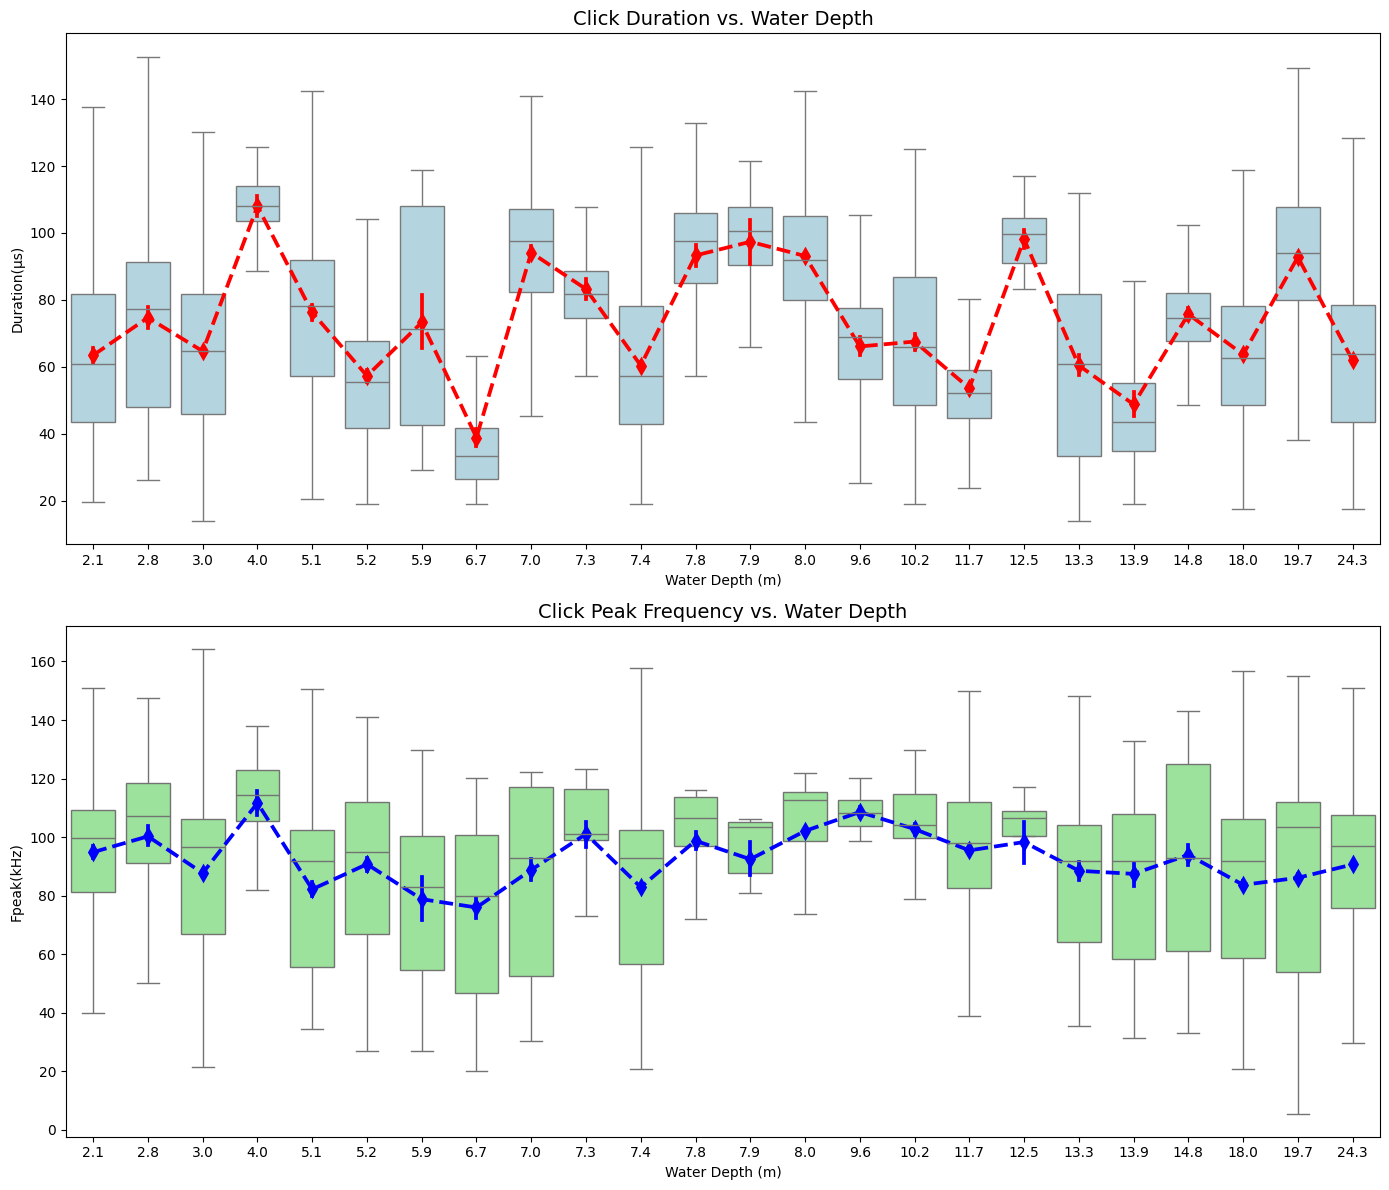


[各深度统计摘要表]


Water_Depth Duration(μs)                            Fpeak(kHz)             \
                       mean        std   median count        mean        std   
0          2.1    63.432582  22.775802   60.760   488   94.868217  23.528652   
1          2.8    74.680915  25.958108   77.240   284  100.286866  27.779527   
2          3.0    64.650998  21.699424   64.640  2775   87.736328  25.750988   
3          4.0   108.005075  12.209125  108.060    67  111.668507  17.515811   
4          5.1    76.241637  24.632675   78.115   446   82.200247  26.395674   
5          5.2    57.292835  22.219696   55.560   589   90.779100  27.616299   
6          5.9    73.239538  31.404864   71.180    65   78.820615  30.685357   
7          6.7    38.850541  21.213702   33.390   259   75.992085  28.291770   
8          7.0    94.113887  17.378077   97.620   319   88.819781  31.912017   
9          7.3    83.229881  14.698093   81.600    84  101.082857  18.809894   
10         7.4    60.374431  22.729484   57.290  1740   82.936069  26.890059   
11         7.8    93.273098  24.826027   97.640   255   98.780353  23.796064   
12         7.9    97.363111  22.997683  100.670    45   92.468444  18.617537   
13         8.0    93.118903  19.194894   92.010  1896  102.124921  23.007853   
14         9.6    66.064968  17.051458   68.980   155  108.589032  11.076499   
15        10.2    67.533182  23.874602   65.970   396  102.768687  20.394421   
16        11.7    53.591420  15.283578   52.080  1549   95.481885  21.454499   
17        12.5    98.149500   7.949662   99.595    40   98.336500  22.233317   
18        13.3    60.391945  25.804396   60.760   329   88.518815  28.433521   
19        13.9    48.755329  23.527218   43.400   167   87.466168  25.877146   
20        14.8    75.715272  14.547055   74.640   294   93.974524  31.642604   
21        18.0    63.670399  20.823160   62.500  1980   83.701247  30.648104   
22        19.7    92.779483  21.032480   94.150  2245   86.124931  30.534223   
23        24.3    61.929035  22.473122   63.830  2011   90.676430  25.931476   

            
    median  
0    99.76  
1   107.08  
2    96.75  
3   114.41  
4    91.78  
5    95.06  
6    82.85  
7    79.88  
8    92.99  
9   101.25  
10   92.81  
11  106.52  
12  103.50  
13  112.72  
14  108.21  
15  104.06  
16   98.07  
17  106.52  
18   91.87  
19   91.87  
20   92.99  
21   91.87  
22  103.50  
23   96.94

In [10]:
print("--- Click信号统计报告 ---")
print(f"检测到不同深度数量: {len(depths)}")
print("\n[显著性分析结果 - Kruskal-Wallis Test]")
print(f"Duration(μs): H-statistic = {h_stat_dur:.2f}, p-value = {p_val_dur:.4e}")
print(f"Fpeak(kHz): H-statistic = {h_stat_fpeak:.2f}, p-value = {p_val_fpeak:.4e}")
if p_val_dur < 0.05:
    print("结论: 不同深度下的 Click 持续时间存在显著差异 (p < 0.05)")
if p_val_fpeak < 0.05:
    print("结论: 不同深度下的 峰值频率 存在显著差异 (p < 0.05)")

# 绘图
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 图1: Duration 随深度的变化
sns.boxplot(x='Water_Depth', y='Duration(μs)', data=full_data, ax=axes[0], color='lightblue', showfliers=False)
sns.pointplot(x='Water_Depth', y='Duration(μs)', data=full_data, ax=axes[0], color='red', markers='d', linestyles='--')
axes[0].set_title('Click Duration vs. Water Depth', fontsize=14)
axes[0].set_xlabel('Water Depth (m)')

# 图2: Fpeak 随深度的变化
sns.boxplot(x='Water_Depth', y='Fpeak(kHz)', data=full_data, ax=axes[1], color='lightgreen', showfliers=False)
sns.pointplot(x='Water_Depth', y='Fpeak(kHz)', data=full_data, ax=axes[1], color='blue', markers='d', linestyles='--')
axes[1].set_title('Click Peak Frequency vs. Water Depth', fontsize=14)
axes[1].set_xlabel('Water Depth (m)')

plt.tight_layout()
plt.show()

# 显示前10行统计摘要
print("\n[各深度统计摘要表]")
display(stats_report)

In [ ]:
# # 如果需要保存统计结果到Excel
# stats_report.to_excel("Click_Depth_Statistics_Report.xlsx", index=False)

# # 如果需要保存合并后的原始数据
# full_data.to_csv("Processed_Click_Data.csv", index=False)

# print("数据已保存至当前工作目录。")